In [1]:
import pandas as pd
import numpy as np
import json
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# ============================================================
# 🔧 CONFIGURACIÓN (JSON-driven)
# ============================================================
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

# Cargar config de display
with open(PROJECT_ROOT / "config" / "base_config.json", 'r', encoding='utf-8') as f:
    base_cfg = json.load(f)

disp = base_cfg.get('display_config', {})
SEP = disp.get('separator_char', '=') * disp.get('separator_length', 70)
IND = disp.get('indent', '   ')
PREFIX = disp.get('prefix_dataset', '📦 ')

# Cargar master_table
master_path = PROJECT_ROOT / "data" / "master" / "master_table.parquet"
df = pd.read_parquet(master_path)

print(f"\n{SEP}")
print("✅ CELDA 1 - CONFIGURACIÓN Y CARGA DE DATOS")
print(SEP)
print(f"{IND}{PREFIX}master_table cargado: {len(df):,} filas × {len(df.columns)} cols")
print(f"{IND}{PREFIX}Municipios únicos: {df['cod_municipio'].nunique()}")
print(f"{IND}{PREFIX}Período: {df['anio_hecho'].min()} - {df['anio_hecho'].max()}")

# Identificar columnas de brechas
brechas_cols = [c for c in df.columns if c.startswith('brecha_')]
print(f"{IND}{PREFIX}Columnas de brechas: {len(brechas_cols)}")
for b in brechas_cols:
    print(f"{IND}{IND}• {b}")
print(SEP)


✅ CELDA 1 - CONFIGURACIÓN Y CARGA DE DATOS
   📦 master_table cargado: 1,432 filas × 31 cols
   📦 Municipios únicos: 179
   📦 Período: 2018 - 2025
   📦 Columnas de brechas: 4
      • brecha_vif_nna
      • brecha_vif_adultas
      • brecha_sexual_nna
      • brecha_sexual_adultas


In [2]:
# ============================================================
# 📊 ANÁLISIS DESCRIPTIVO DE BRECHAS
# ============================================================

print(f"\n{SEP}")
print("📊 CELDA 2 - ESTADÍSTICAS DESCRIPTIVAS DE BRECHAS")
print(SEP)

brechas_cols = [c for c in df.columns if c.startswith('brecha_')]
stats_brechas = {}

for b in brechas_cols:
    validos = df[b].notna().sum()
    porcentaje = validos / len(df) * 100

    stats_brechas[b] = {
        'total_filas': int(len(df)),
        'valores_validos': int(validos),
        'porcentaje_validos': round(porcentaje, 1),
        'media': round(df[b].mean(), 2),
        'mediana': round(df[b].median(), 2),
        'min': round(df[b].min(), 2) if pd.notna(df[b].min()) else None,
        'max': round(df[b].max(), 2) if pd.notna(df[b].max()) else None,
        'std': round(df[b].std(), 2) if pd.notna(df[b].std()) else None,
        'interpretacion': 'Mayor afectación femenina' if df[b].mean() > 1 else 'Paridad'
    }

    print(f"\n{IND}🔍 {b}:")
    print(f"{IND}{PREFIX}Valores válidos: {validos} de {len(df)} ({porcentaje:.1f}%)")
    print(f"{IND}{PREFIX}Media: {stats_brechas[b]['media']}")
    print(f"{IND}{PREFIX}Mediana: {stats_brechas[b]['mediana']}")
    print(f"{IND}{PREFIX}Rango: {stats_brechas[b]['min']} - {stats_brechas[b]['max']}")
    print(f"{IND}{PREFIX}Desv. estándar: {stats_brechas[b]['std']}")
    print(f"{IND}{PREFIX}Interpretación: {stats_brechas[b]['interpretacion']}")

print(f"\n{SEP}")
print("✅ CELDA 2 - ESTADÍSTICAS DESCRIPTIVAS COMPLETADAS")
print(SEP)


📊 CELDA 2 - ESTADÍSTICAS DESCRIPTIVAS DE BRECHAS

   🔍 brecha_vif_nna:
   📦 Valores válidos: 372 de 1432 (26.0%)
   📦 Media: 1.67
   📦 Mediana: 1.34
   📦 Rango: 0.0 - 12.36
   📦 Desv. estándar: 1.54
   📦 Interpretación: Mayor afectación femenina

   🔍 brecha_vif_adultas:
   📦 Valores válidos: 1019 de 1432 (71.2%)
   📦 Media: 4.97
   📦 Mediana: 3.89
   📦 Rango: 0.0 - 36.86
   📦 Desv. estándar: 4.17
   📦 Interpretación: Mayor afectación femenina

   🔍 brecha_sexual_nna:
   📦 Valores válidos: 416 de 1432 (29.1%)
   📦 Media: 4.86
   📦 Mediana: 4.29
   📦 Rango: 0.0 - 34.71
   📦 Desv. estándar: 4.24
   📦 Interpretación: Mayor afectación femenina

   🔍 brecha_sexual_adultas:
   📦 Valores válidos: 608 de 1432 (42.5%)
   📦 Media: 5.08
   📦 Mediana: 4.29
   📦 Rango: 0.0 - 28.85
   📦 Desv. estándar: 3.92
   📦 Interpretación: Mayor afectación femenina

✅ CELDA 2 - ESTADÍSTICAS DESCRIPTIVAS COMPLETADAS


In [3]:
# ============================================================
# 🏆 TOP MUNICIPIOS CON BRECHAS MÁS ALTAS
# ============================================================

print(f"\n{SEP}")
print("🏆 CELDA 3 - TOP MUNICIPIOS CON BRECHAS MÁS ALTAS")
print(SEP)

# Calcular brechas promedio por municipio (colapsando años)
df_municipio = df.groupby('cod_municipio').agg({
    'municipio': 'first',
    'departamento': 'first',
    'brecha_vif_nna': 'mean',
    'brecha_vif_adultas': 'mean',
    'brecha_sexual_nna': 'mean',
    'brecha_sexual_adultas': 'mean'
}).reset_index()

# Calcular brecha promedio general usando MEDIANA (más robusto que media)
df_municipio['brecha_promedio'] = df_municipio[[
    'brecha_vif_nna', 'brecha_vif_adultas',
    'brecha_sexual_nna', 'brecha_sexual_adultas'
]].median(axis=1, skipna=True)

# Top 10 municipios con brecha más alta
top10 = df_municipio.nlargest(10, 'brecha_promedio')

print(f"\n{IND}📊 Top 10 municipios con mayor brecha de género (2018-2025):")
print(f"{IND}{PREFIX}Criterio: MEDIANA de las 4 brechas (más robusto que media)")
print()

# ✅ CORREGIDO: usar enumerate para numeración correcta 1-10
for rank, (idx, row) in enumerate(top10.iterrows(), start=1):
    print(f"{IND}{rank:2d}. {row['municipio']} ({row['departamento']})")
    print(f"{IND}{IND}• Brecha mediana: {row['brecha_promedio']:.2f}x")
    print(f"{IND}{IND}• VIF NNA: {row['brecha_vif_nna']:.2f}" if pd.notna(row['brecha_vif_nna']) else f"{IND}{IND}• VIF NNA: N/A")
    print(f"{IND}{IND}• VIF Adultas: {row['brecha_vif_adultas']:.2f}" if pd.notna(row['brecha_vif_adultas']) else f"{IND}{IND}• VIF Adultas: N/A")
    print(f"{IND}{IND}• Sexual NNA: {row['brecha_sexual_nna']:.2f}" if pd.notna(row['brecha_sexual_nna']) else f"{IND}{IND}• Sexual NNA: N/A")
    print(f"{IND}{IND}• Sexual Adultas: {row['brecha_sexual_adultas']:.2f}" if pd.notna(row['brecha_sexual_adultas']) else f"{IND}{IND}• Sexual Adultas: N/A")
    print()

# Guardar top10
top10_dict = top10.to_dict('records')
print(f"{SEP}")
print("✅ CELDA 3 - TOP 10 MUNICIPIOS IDENTIFICADOS")
print(SEP)


🏆 CELDA 3 - TOP MUNICIPIOS CON BRECHAS MÁS ALTAS

   📊 Top 10 municipios con mayor brecha de género (2018-2025):
   📦 Criterio: MEDIANA de las 4 brechas (más robusto que media)

    1. EL TAMBO (CAUCA)
      • Brecha mediana: 10.37x
      • VIF NNA: 2.73
      • VIF Adultas: 11.04
      • Sexual NNA: 10.21
      • Sexual Adultas: 10.54

    2. TORIBIO (CAUCA)
      • Brecha mediana: 9.12x
      • VIF NNA: 1.03
      • VIF Adultas: 11.00
      • Sexual NNA: 16.46
      • Sexual Adultas: 7.23

    3. MORALES (CAUCA)
      • Brecha mediana: 7.79x
      • VIF NNA: 1.28
      • VIF Adultas: 9.13
      • Sexual NNA: 6.44
      • Sexual Adultas: 10.57

    4. SANTANDER DE QUILICHAO (CAUCA)
      • Brecha mediana: 7.72x
      • VIF NNA: 3.53
      • VIF Adultas: 5.10
      • Sexual NNA: 11.64
      • Sexual Adultas: 10.33

    5. CAJIBIO (CAUCA)
      • Brecha mediana: 7.47x
      • VIF NNA: 2.68
      • VIF Adultas: 7.44
      • Sexual NNA: 7.50
      • Sexual Adultas: 13.80

    6. ARGELIA 

In [4]:
# ============================================================
# 📈 EVOLUCIÓN TEMPORAL DE BRECHAS (2018-2025)
# ============================================================

print(f"\n{SEP}")
print("📈 CELDA 4 - EVOLUCIÓN TEMPORAL DE BRECHAS")
print(SEP)

# Calcular brecha promedio por año
df_temporal = df.groupby('anio_hecho').agg({
    'brecha_vif_nna': 'mean',
    'brecha_vif_adultas': 'mean',
    'brecha_sexual_nna': 'mean',
    'brecha_sexual_adultas': 'mean'
}).reset_index()

print(f"\n{IND}📊 Evolución de brechas promedio por año:")
print(f"{IND}{PREFIX}Cada valor es el promedio de todos los municipios para ese año")
print()

for _, row in df_temporal.iterrows():
    print(f"{IND}📅 {int(row['anio_hecho'])}:")
    print(f"{IND}{PREFIX}VIF NNA: {row['brecha_vif_nna']:.2f}" if pd.notna(row['brecha_vif_nna']) else f"{IND}{PREFIX}VIF NNA: N/A")
    print(f"{IND}{PREFIX}VIF Adultas: {row['brecha_vif_adultas']:.2f}" if pd.notna(row['brecha_vif_adultas']) else f"{IND}{PREFIX}VIF Adultas: N/A")
    print(f"{IND}{PREFIX}Sexual NNA: {row['brecha_sexual_nna']:.2f}" if pd.notna(row['brecha_sexual_nna']) else f"{IND}{PREFIX}Sexual NNA: N/A")
    print(f"{IND}{PREFIX}Sexual Adultas: {row['brecha_sexual_adultas']:.2f}" if pd.notna(row['brecha_sexual_adultas']) else f"{IND}{PREFIX}Sexual Adultas: N/A")
    print()

# Calcular tendencia (pendiente de regresión lineal)
from scipy import stats

tendencias = {}
for b in ['brecha_vif_nna', 'brecha_vif_adultas', 'brecha_sexual_nna', 'brecha_sexual_adultas']:
    x = df_temporal['anio_hecho'].values
    y = df_temporal[b].values

    # Eliminar NaN
    mask = ~np.isnan(y)
    if mask.sum() > 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
        tendencias[b] = {
            'pendiente': round(slope, 4),
            'r2': round(r_value**2, 4),
            'p_value': round(p_value, 4),
            'tendencia': 'Aumentando' if slope > 0 else 'Disminuyendo' if slope < 0 else 'Estable',
            'significativa': p_value < 0.05
        }
    else:
        tendencias[b] = {
            'pendiente': None,
            'r2': None,
            'p_value': None,
            'tendencia': 'Datos insuficientes',
            'significativa': False
        }

print(f"\n{IND}📊 Análisis de tendencias (regresión lineal):")
for b, t in tendencias.items():
    print(f"\n{IND}🔍 {b}:")
    print(f"{IND}{PREFIX}Pendiente: {t['pendiente']}")
    print(f"{IND}{PREFIX}R²: {t['r2']}")
    print(f"{IND}{PREFIX}p-value: {t['p_value']}")
    print(f"{IND}{PREFIX}Tendencia: {t['tendencia']}")
    print(f"{IND}{PREFIX}¿Significativa? {'✅ Sí' if t['significativa'] else '❌ No'}")

# Guardar evolución temporal
df_temporal_dict = df_temporal.to_dict('records')
print(f"\n{SEP}")
print("✅ CELDA 4 - EVOLUCIÓN TEMPORAL ANALIZADA")
print(SEP)


📈 CELDA 4 - EVOLUCIÓN TEMPORAL DE BRECHAS

   📊 Evolución de brechas promedio por año:
   📦 Cada valor es el promedio de todos los municipios para ese año

   📅 2018:
   📦 VIF NNA: 1.67
   📦 VIF Adultas: 6.93
   📦 Sexual NNA: 6.31
   📦 Sexual Adultas: 7.19

   📅 2019:
   📦 VIF NNA: 2.05
   📦 VIF Adultas: 5.43
   📦 Sexual NNA: 5.03
   📦 Sexual Adultas: 5.63

   📅 2020:
   📦 VIF NNA: 1.58
   📦 VIF Adultas: 5.90
   📦 Sexual NNA: 4.90
   📦 Sexual Adultas: 4.27

   📅 2021:
   📦 VIF NNA: 2.16
   📦 VIF Adultas: 4.50
   📦 Sexual NNA: 5.31
   📦 Sexual Adultas: 4.86

   📅 2022:
   📦 VIF NNA: 1.64
   📦 VIF Adultas: 5.01
   📦 Sexual NNA: 4.71
   📦 Sexual Adultas: 4.42

   📅 2023:
   📦 VIF NNA: 1.36
   📦 VIF Adultas: 3.76
   📦 Sexual NNA: 4.34
   📦 Sexual Adultas: 4.63

   📅 2024:
   📦 VIF NNA: 1.46
   📦 VIF Adultas: 4.20
   📦 Sexual NNA: 4.22
   📦 Sexual Adultas: 5.00

   📅 2025:
   📦 VIF NNA: 1.47
   📦 VIF Adultas: 4.51
   📦 Sexual NNA: 3.64
   📦 Sexual Adultas: 4.65


   📊 Análisis de tendencia

In [5]:
# ============================================================
# 🔗 CORRELACIÓN ENTRE BRECHAS E ICV-GEN-F
# ============================================================

print(f"\n{SEP}")
print("🔗 CELDA 5 - CORRELACIÓN BRECHAS vs ICV-GEN-F")
print(SEP)

# Calcular ICV promedio por municipio
df_corr = df.groupby('cod_municipio').agg({
    'municipio': 'first',
    'departamento': 'first',
    'icv_gen_f_score': 'mean',
    'brecha_vif_nna': 'mean',
    'brecha_vif_adultas': 'mean',
    'brecha_sexual_nna': 'mean',
    'brecha_sexual_adultas': 'mean'
}).reset_index()

# Calcular correlaciones (Spearman, robusto a outliers)
correlaciones = {}
for b in ['brecha_vif_nna', 'brecha_vif_adultas', 'brecha_sexual_nna', 'brecha_sexual_adultas']:
    mask = df_corr[['icv_gen_f_score', b]].notna().all(axis=1)
    if mask.sum() > 10:
        corr, p_value = stats.spearmanr(df_corr.loc[mask, 'icv_gen_f_score'], df_corr.loc[mask, b])
        correlaciones[b] = {
            'spearman_rho': round(corr, 4),
            'p_value': round(p_value, 4),
            'significativa': p_value < 0.05,
            'interpretacion': 'Positiva (mayor severidad → mayor brecha)' if corr > 0 else 'Negativa (mayor severidad → menor brecha)' if corr < 0 else 'Sin correlación'
        }
    else:
        correlaciones[b] = {
            'spearman_rho': None,
            'p_value': None,
            'significativa': False,
            'interpretacion': 'Datos insuficientes'
        }

print(f"\n{IND}📊 Correlación Spearman entre ICV-GEN-F y brechas:")
print(f"{IND}{PREFIX}Pregunta: ¿Municipios con alto ICV también tienen brechas altas?")
print()

for b, c in correlaciones.items():
    print(f"{IND}🔍 {b}:")
    print(f"{IND}{PREFIX}Spearman ρ: {c['spearman_rho']}")
    print(f"{IND}{PREFIX}p-value: {c['p_value']}")
    print(f"{IND}{PREFIX}¿Significativa? {'✅ Sí' if c['significativa'] else '❌ No'}")
    print(f"{IND}{PREFIX}Interpretación: {c['interpretacion']}")
    print()

# Análisis de cuartiles
print(f"\n{IND}📊 Análisis por cuartiles de ICV:")
df_corr['icv_cuartil'] = pd.qcut(df_corr['icv_gen_f_score'], q=4, labels=['Q1 (Bajo)', 'Q2', 'Q3', 'Q4 (Alto)'])

for b in ['brecha_vif_adultas', 'brecha_sexual_adultas']:
    print(f"\n{IND}🔍 {b} por cuartil de ICV:")
    for cuartil in ['Q1 (Bajo)', 'Q2', 'Q3', 'Q4 (Alto)']:
        media = df_corr[df_corr['icv_cuartil'] == cuartil][b].mean()
        print(f"{IND}{PREFIX}{cuartil}: {media:.2f}" if pd.notna(media) else f"{IND}{PREFIX}{cuartil}: N/A")

# Guardar correlaciones
print(f"\n{SEP}")
print("✅ CELDA 5 - CORRELACIONES ANALIZADAS")
print(SEP)


🔗 CELDA 5 - CORRELACIÓN BRECHAS vs ICV-GEN-F

   📊 Correlación Spearman entre ICV-GEN-F y brechas:
   📦 Pregunta: ¿Municipios con alto ICV también tienen brechas altas?

   🔍 brecha_vif_nna:
   📦 Spearman ρ: 0.4513
   📦 p-value: 0.0
   📦 ¿Significativa? ✅ Sí
   📦 Interpretación: Positiva (mayor severidad → mayor brecha)

   🔍 brecha_vif_adultas:
   📦 Spearman ρ: 0.3895
   📦 p-value: 0.0
   📦 ¿Significativa? ✅ Sí
   📦 Interpretación: Positiva (mayor severidad → mayor brecha)

   🔍 brecha_sexual_nna:
   📦 Spearman ρ: 0.4943
   📦 p-value: 0.0
   📦 ¿Significativa? ✅ Sí
   📦 Interpretación: Positiva (mayor severidad → mayor brecha)

   🔍 brecha_sexual_adultas:
   📦 Spearman ρ: 0.481
   📦 p-value: 0.0
   📦 ¿Significativa? ✅ Sí
   📦 Interpretación: Positiva (mayor severidad → mayor brecha)


   📊 Análisis por cuartiles de ICV:

   🔍 brecha_vif_adultas por cuartil de ICV:
   📦 Q1 (Bajo): 2.50
   📦 Q2: 5.21
   📦 Q3: 5.44
   📦 Q4 (Alto): 5.03

   🔍 brecha_sexual_adultas por cuartil de ICV:
   📦

In [6]:
# ============================================================
# 💾 GUARDAR RESULTADOS EN JSON
# ============================================================

print(f"\n{SEP}")
print("💾 CELDA 6 - GUARDAR RESULTADOS")
print(SEP)

# Función auxiliar para convertir tipos numpy a tipos nativos de Python
def convertir_tipos(obj):
    """Convierte tipos numpy a tipos nativos de Python para serialización JSON."""
    if isinstance(obj, dict):
        return {k: convertir_tipos(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convertir_tipos(item) for item in obj]
    elif isinstance(obj, (np.bool_, np.generic)):
        return obj.item()
    elif pd.isna(obj):
        return None
    else:
        return obj

# Estructura de resultados (con conversión de tipos)
resultados_brechas = {
    "metadata": {
        "descripcion": "Análisis de brechas de género en violencia contra mujeres y niñas",
        "periodo": "2018-2025",
        "total_municipios": int(df['cod_municipio'].nunique()),
        "total_filas": int(len(df)),
        "metodo_calculo_top10": "mediana (más robusto que media)"
    },
    "estadisticas_descriptivas": convertir_tipos(stats_brechas),
    "top10_municipios": convertir_tipos(top10_dict),
    "evolucion_temporal": {
        "datos_anuales": convertir_tipos(df_temporal_dict),
        "tendencias": convertir_tipos(tendencias)
    },
    "correlaciones_icv": convertir_tipos(correlaciones),
    "hallazgos_clave": {
        "brecha_mas_alta": max(stats_brechas.items(), key=lambda x: x[1]['media'])[0],
        "brecha_mas_baja": min(stats_brechas.items(), key=lambda x: x[1]['media'])[0],
        "municipio_mayor_brecha": top10.iloc[0]['municipio'] if len(top10) > 0 else None,
        "correlacion_fuerte": bool(any(c['spearman_rho'] and abs(c['spearman_rho']) > 0.5 for c in correlaciones.values())),
        "tendencia_significativa": bool(any(t['significativa'] for t in tendencias.values()))
    }
}

# Guardar JSON
output_path = PROJECT_ROOT / "docs" / "analisis_brechas.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(resultados_brechas, f, indent=2, ensure_ascii=False)

print(f"\n{IND}💾 Resultados guardados: {output_path}")
print(f"{IND}{PREFIX}Tamaño: {len(json.dumps(resultados_brechas))} caracteres")
print(f"{IND}{PREFIX}Método Top 10: mediana (skipna=True)")
print(f"\n{SEP}")
print("✅ CELDA 6 - RESULTADOS GUARDADOS")
print(SEP)

# Resumen final
print(f"\n{SEP}")
print("🎯 RESUMEN EJECUTIVO - ANÁLISIS DE BRECHAS")
print(SEP)
print(f"{IND}📊 Hallazgos clave:")
print(f"{IND}{PREFIX}• Brecha más alta: {resultados_brechas['hallazgos_clave']['brecha_mas_alta']}")
print(f"{IND}{PREFIX}• Brecha más baja: {resultados_brechas['hallazgos_clave']['brecha_mas_baja']}")
print(f"{IND}{PREFIX}• Municipio con mayor brecha: {resultados_brechas['hallazgos_clave']['municipio_mayor_brecha']}")
print(f"{IND}{PREFIX}• ¿Correlación fuerte con ICV? {'✅ Sí' if resultados_brechas['hallazgos_clave']['correlacion_fuerte'] else '❌ No'}")
print(f"{IND}{PREFIX}• ¿Tendencia temporal significativa? {'✅ Sí' if resultados_brechas['hallazgos_clave']['tendencia_significativa'] else '❌ No'}")
print(f"\n{SEP}")
print("✅ ANÁLISIS DE BRECHAS COMPLETADO")
print(SEP)


💾 CELDA 6 - GUARDAR RESULTADOS

   💾 Resultados guardados: /Users/anaaguirre/Documents/Cicatrices_invisibles/docs/analisis_brechas.json
   📦 Tamaño: 6859 caracteres
   📦 Método Top 10: mediana (skipna=True)

✅ CELDA 6 - RESULTADOS GUARDADOS

🎯 RESUMEN EJECUTIVO - ANÁLISIS DE BRECHAS
   📊 Hallazgos clave:
   📦 • Brecha más alta: brecha_sexual_adultas
   📦 • Brecha más baja: brecha_vif_nna
   📦 • Municipio con mayor brecha: EL TAMBO
   📦 • ¿Correlación fuerte con ICV? ❌ No
   📦 • ¿Tendencia temporal significativa? ✅ Sí

✅ ANÁLISIS DE BRECHAS COMPLETADO



📈 CELDA 7 - VISUALIZACIONES DE BRECHAS (Seaborn)

   📊 Creando Gráfico 1: Comparación de brechas...


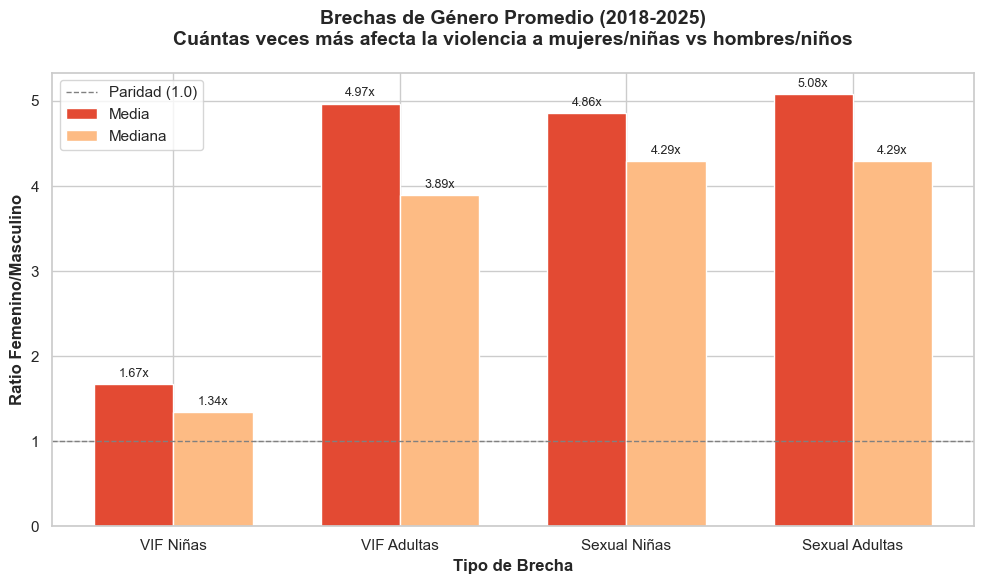

   📦 ✅ Gráfico 1 completado

   📊 Creando Gráfico 2: Evolución temporal...


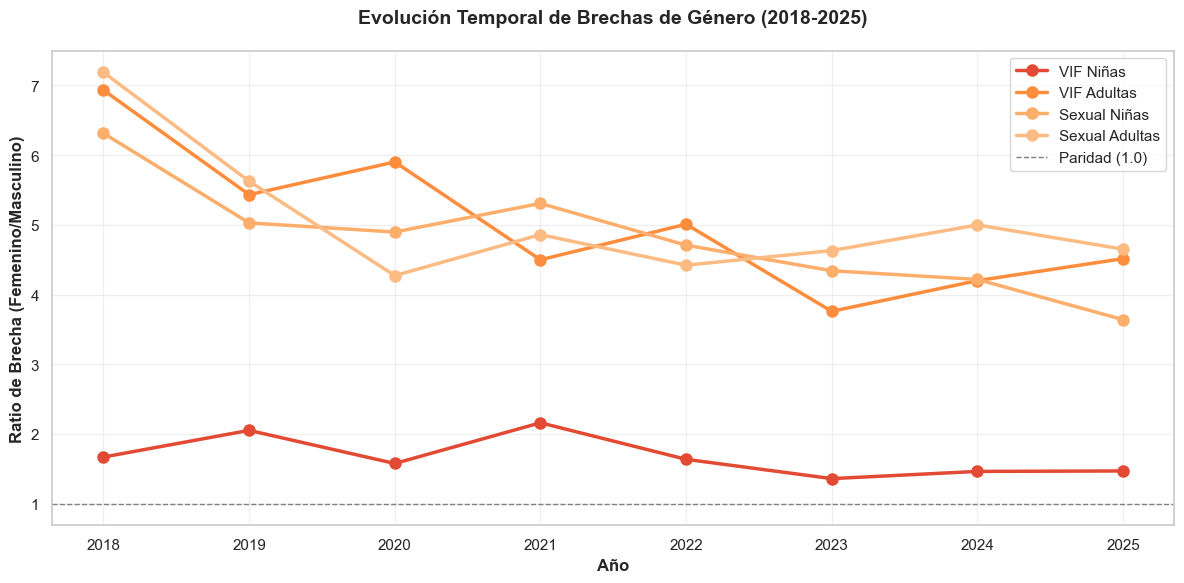

   📦 ✅ Gráfico 2 completado

   📊 Creando Gráfico 3: ICV vs Brechas...


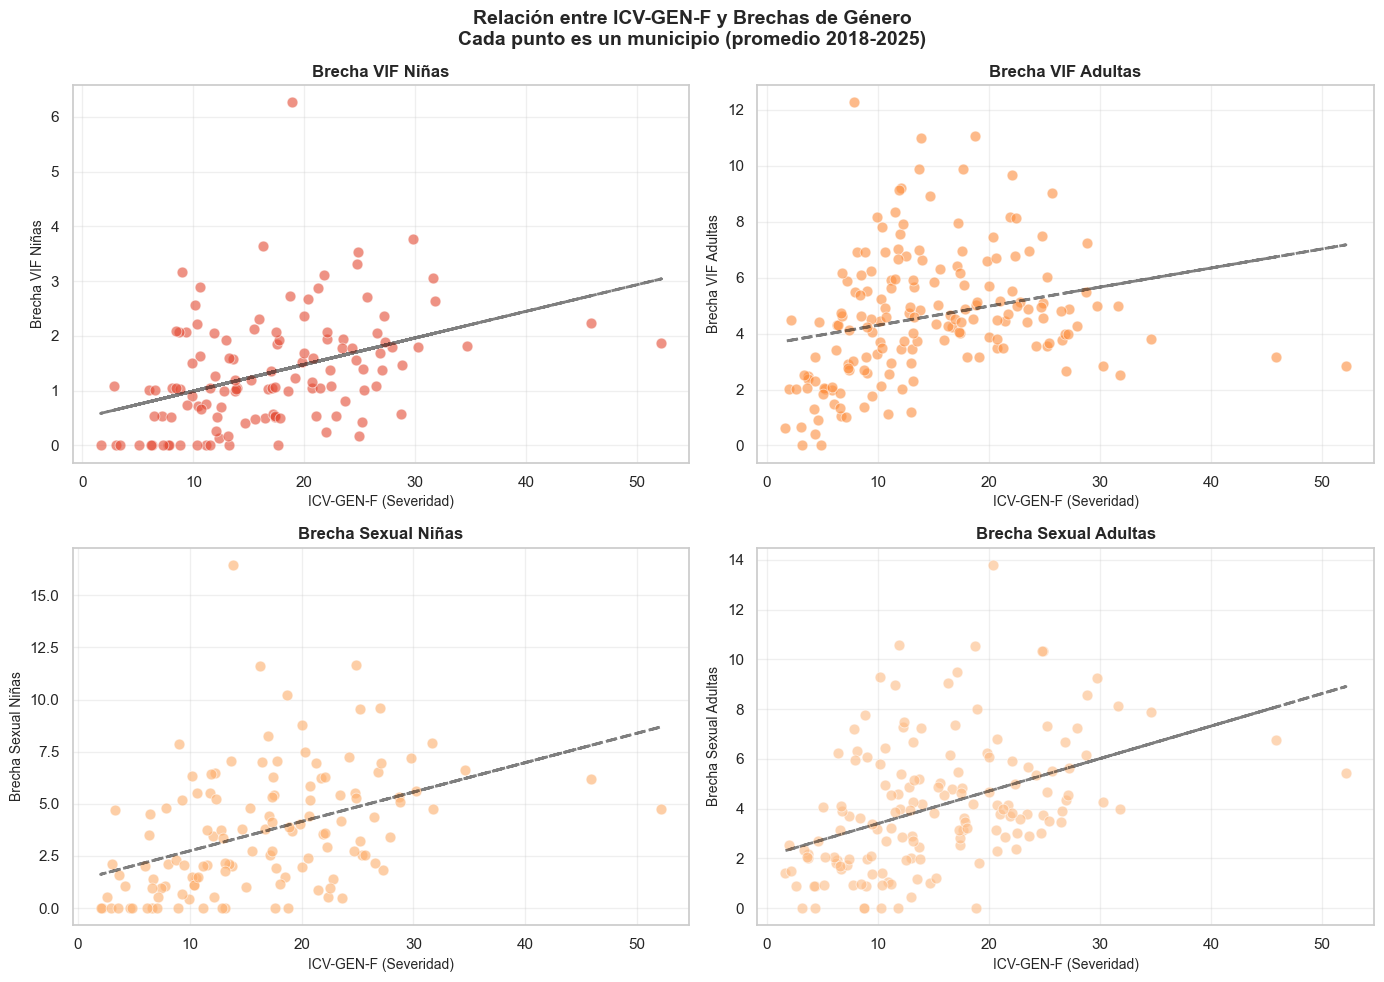

   📦 ✅ Gráfico 3 completado

   📊 Creando Gráfico 4: Top 10 municipios...


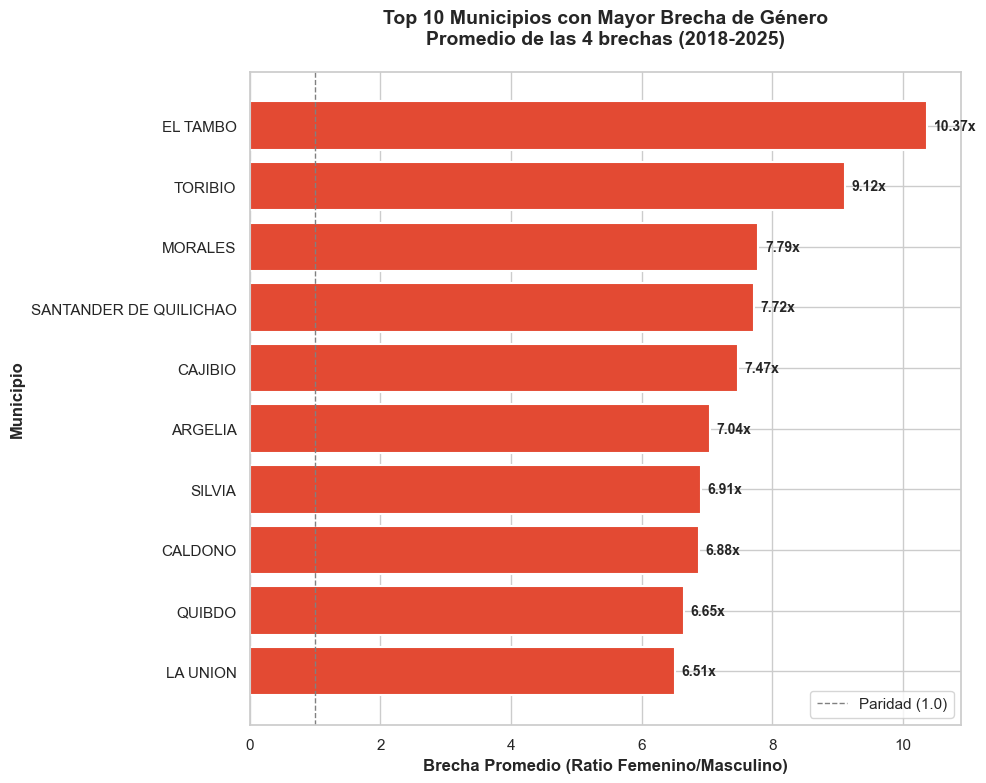

   📦 ✅ Gráfico 4 completado

   📊 Creando Gráfico 5: Boxplot de distribución...


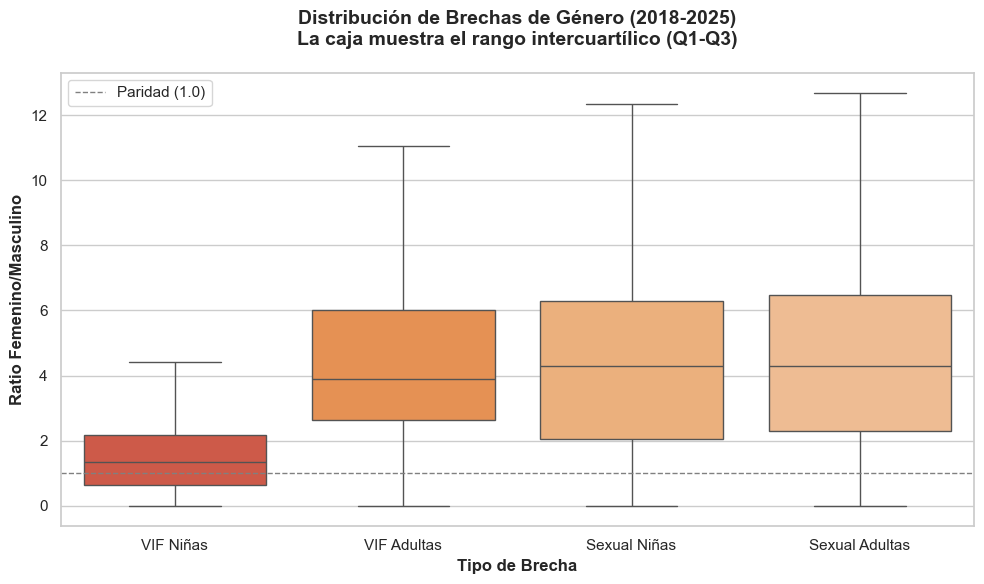

   📦 ✅ Gráfico 5 completado

✅ CELDA 7 - VISUALIZACIONES COMPLETADAS
   📊 Total de gráficos generados: 5
   📦 1. Comparación de brechas (barras)
   📦 2. Evolución temporal (líneas)
   📦 3. ICV vs Brechas (scatter 2x2)
   📦 4. Top 10 municipios (barras horizontales)
   📦 5. Boxplot de distribución



In [7]:
# ============================================================
# 📈 VISUALIZACIONES DE BRECHAS (Seaborn + Matplotlib)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Silencia warnings de matplotlib/seaborn

# Configurar estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print(f"\n{SEP}")
print("📈 CELDA 7 - VISUALIZACIONES DE BRECHAS (Seaborn)")
print(SEP)

# ============================================================
# GRÁFICO 1: Comparación de las 4 brechas (barras)
# ============================================================

print(f"\n{IND}📊 Creando Gráfico 1: Comparación de brechas...")

fig1, ax1 = plt.subplots(figsize=(10, 6))

df_barras = pd.DataFrame({
    'Tipo de Brecha': ['VIF Niñas', 'VIF Adultas', 'Sexual Niñas', 'Sexual Adultas'],
    'Media': [stats_brechas['brecha_vif_nna']['media'],
              stats_brechas['brecha_vif_adultas']['media'],
              stats_brechas['brecha_sexual_nna']['media'],
              stats_brechas['brecha_sexual_adultas']['media']],
    'Mediana': [stats_brechas['brecha_vif_nna']['mediana'],
                stats_brechas['brecha_vif_adultas']['mediana'],
                stats_brechas['brecha_sexual_nna']['mediana'],
                stats_brechas['brecha_sexual_adultas']['mediana']]
})

x = np.arange(len(df_barras))
width = 0.35

bars1 = ax1.bar(x - width/2, df_barras['Media'], width, label='Media', color='#e34a33')
bars2 = ax1.bar(x + width/2, df_barras['Mediana'], width, label='Mediana', color='#fdbb84')

ax1.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Paridad (1.0)')

ax1.set_xlabel('Tipo de Brecha', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ratio Femenino/Masculino', fontsize=12, fontweight='bold')
ax1.set_title('Brechas de Género Promedio (2018-2025)\nCuántas veces más afecta la violencia a mujeres/niñas vs hombres/niños',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(df_barras['Tipo de Brecha'])
ax1.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}x',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print(f"{IND}{PREFIX}✅ Gráfico 1 completado")

# ============================================================
# GRÁFICO 2: Evolución temporal (líneas)
# ============================================================

print(f"\n{IND}📊 Creando Gráfico 2: Evolución temporal...")

fig2, ax2 = plt.subplots(figsize=(12, 6))

colores = ['#e34a33', '#fd8d3c', '#fdae6b', '#fdbb84']
nombres = {
    'brecha_vif_nna': 'VIF Niñas',
    'brecha_vif_adultas': 'VIF Adultas',
    'brecha_sexual_nna': 'Sexual Niñas',
    'brecha_sexual_adultas': 'Sexual Adultas'
}

for i, (col, nombre) in enumerate(nombres.items()):
    ax2.plot(df_temporal['anio_hecho'], df_temporal[col],
             marker='o', linewidth=2.5, markersize=8,
             color=colores[i], label=nombre)

ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Paridad (1.0)')

ax2.set_xlabel('Año', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ratio de Brecha (Femenino/Masculino)', fontsize=12, fontweight='bold')
ax2.set_title('Evolución Temporal de Brechas de Género (2018-2025)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(df_temporal['anio_hecho'])
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"{IND}{PREFIX}✅ Gráfico 2 completado")

# ============================================================
# GRÁFICO 3: Scatter plot ICV vs Brechas (2x2)
# ============================================================

print(f"\n{IND}📊 Creando Gráfico 3: ICV vs Brechas...")

fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle('Relación entre ICV-GEN-F y Brechas de Género\nCada punto es un municipio (promedio 2018-2025)',
              fontsize=14, fontweight='bold', y=0.98)

brechas_scatter = ['brecha_vif_nna', 'brecha_vif_adultas', 'brecha_sexual_nna', 'brecha_sexual_adultas']
titulos = ['VIF Niñas', 'VIF Adultas', 'Sexual Niñas', 'Sexual Adultas']
colores_scatter = ['#e34a33', '#fd8d3c', '#fdae6b', '#fdbb84']

for i, (brecha, titulo, color) in enumerate(zip(brechas_scatter, titulos, colores_scatter)):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    df_scatter = df_corr[['icv_gen_f_score', brecha]].dropna()

    sns.scatterplot(data=df_scatter, x='icv_gen_f_score', y=brecha,
                   ax=ax, color=color, alpha=0.6, s=60, edgecolor='white')

    if len(df_scatter) > 2:
        z = np.polyfit(df_scatter['icv_gen_f_score'], df_scatter[brecha], 1)
        p = np.poly1d(z)
        ax.plot(df_scatter['icv_gen_f_score'], p(df_scatter['icv_gen_f_score']),
               "--", color='black', alpha=0.5, linewidth=2)

    ax.set_xlabel('ICV-GEN-F (Severidad)', fontsize=10)
    ax.set_ylabel(f'Brecha {titulo}', fontsize=10)
    ax.set_title(f'Brecha {titulo}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"{IND}{PREFIX}✅ Gráfico 3 completado")

# ============================================================
# GRÁFICO 4: Top 10 municipios (barras horizontales)
# ============================================================

print(f"\n{IND}📊 Creando Gráfico 4: Top 10 municipios...")

fig4, ax4 = plt.subplots(figsize=(10, 8))

top10_sorted = top10.sort_values('brecha_promedio', ascending=True)

bars = ax4.barh(top10_sorted['municipio'], top10_sorted['brecha_promedio'],
                color='#e34a33', edgecolor='white', linewidth=1.5)

ax4.axvline(x=1, color='gray', linestyle='--', linewidth=1, label='Paridad (1.0)')

ax4.set_xlabel('Brecha Promedio (Ratio Femenino/Masculino)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Municipio', fontsize=12, fontweight='bold')
ax4.set_title('Top 10 Municipios con Mayor Brecha de Género\nPromedio de las 4 brechas (2018-2025)',
              fontsize=14, fontweight='bold', pad=20)

for i, (idx, row) in enumerate(top10_sorted.iterrows()):
    ax4.text(row['brecha_promedio'] + 0.1, i, f"{row['brecha_promedio']:.2f}x",
            va='center', fontsize=10, fontweight='bold')

ax4.legend()
plt.tight_layout()
plt.show()
print(f"{IND}{PREFIX}✅ Gráfico 4 completado")

# ============================================================
# GRÁFICO 5: Boxplot de distribución de brechas (CORREGIDO)
# ============================================================

print(f"\n{IND}📊 Creando Gráfico 5: Boxplot de distribución...")

fig5, ax5 = plt.subplots(figsize=(10, 6))

df_box = df.melt(
    id_vars=['cod_municipio', 'anio_hecho'],
    value_vars=['brecha_vif_nna', 'brecha_vif_adultas', 'brecha_sexual_nna', 'brecha_sexual_adultas'],
    var_name='Tipo de Brecha',
    value_name='Valor'
).dropna()

mapeo_nombres = {
    'brecha_vif_nna': 'VIF Niñas',
    'brecha_vif_adultas': 'VIF Adultas',
    'brecha_sexual_nna': 'Sexual Niñas',
    'brecha_sexual_adultas': 'Sexual Adultas'
}
df_box['Tipo de Brecha'] = df_box['Tipo de Brecha'].map(mapeo_nombres)

# ✅ CORREGIDO: hue + legend=False (sin FutureWarning)
sns.boxplot(data=df_box, x='Tipo de Brecha', y='Valor',
           hue='Tipo de Brecha',
           palette=['#e34a33', '#fd8d3c', '#fdae6b', '#fdbb84'],
           ax=ax5, showfliers=False, legend=False)

ax5.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Paridad (1.0)')

ax5.set_xlabel('Tipo de Brecha', fontsize=12, fontweight='bold')
ax5.set_ylabel('Ratio Femenino/Masculino', fontsize=12, fontweight='bold')
ax5.set_title('Distribución de Brechas de Género (2018-2025)\nLa caja muestra el rango intercuartílico (Q1-Q3)',
              fontsize=14, fontweight='bold', pad=20)
ax5.legend()
plt.tight_layout()
plt.show()
print(f"{IND}{PREFIX}✅ Gráfico 5 completado")

print(f"\n{SEP}")
print("✅ CELDA 7 - VISUALIZACIONES COMPLETADAS")
print(SEP)
print(f"{IND}📊 Total de gráficos generados: 5")
print(f"{IND}{PREFIX}1. Comparación de brechas (barras)")
print(f"{IND}{PREFIX}2. Evolución temporal (líneas)")
print(f"{IND}{PREFIX}3. ICV vs Brechas (scatter 2x2)")
print(f"{IND}{PREFIX}4. Top 10 municipios (barras horizontales)")
print(f"{IND}{PREFIX}5. Boxplot de distribución")
print(f"\n{SEP}")

In [8]:
# ============================================================
# 🔍 VERIFICACIÓN DE TASAS MASCULINAS (diagnóstico de artefacto)
# Propósito: verificar si la caída de brechas se debe a:
#   (a) disminución real de inequidad (tasas femeninas bajan más)
#   (b) mejora de reporte masculino (tasas masculinas suben)
# ============================================================

import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats

# Cargar configuración de display
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

with open(PROJECT_ROOT / "config" / "base_config.json", 'r', encoding='utf-8') as f:
    base_cfg = json.load(f)

disp = base_cfg.get('display_config', {})
SEP = disp.get('separator_char', '=') * disp.get('separator_length', 70)
IND = disp.get('indent', '   ')
PREFIX = disp.get('prefix_dataset', '📦 ')

# Cargar master_table
master_path = PROJECT_ROOT / "data" / "master" / "master_table.parquet"
df = pd.read_parquet(master_path)

print(f"\n{SEP}")
print("🔍 VERIFICACIÓN DE TASAS MASCULINAS (2018-2025)")
print(SEP)

# Calcular tasas promedio por año
df_temporal_m = df.groupby('anio_hecho').agg({
    'tasa_vif_nna_m': 'mean',
    'tasa_vif_adultos_m': 'mean',
    'tasa_sexual_nna_m': 'mean',
    'tasa_sexual_adultos_m': 'mean',
    'tasa_vif_nna_f': 'mean',
    'tasa_vif_adultas_f': 'mean',
    'tasa_sexual_nna_f': 'mean',
    'tasa_sexual_adultas_f': 'mean'
}).reset_index()

print(f"\n{IND}📊 Evolución de tasas promedio por año (×100k):")
print(f"{IND}{PREFIX}Tasas FEMENINAS:")
for _, row in df_temporal_m.iterrows():
    print(f"{IND}{IND}📅 {int(row['anio_hecho'])}: VIF NNA={row['tasa_vif_nna_f']:.2f} | VIF Ad={row['tasa_vif_adultas_f']:.2f} | Sex NNA={row['tasa_sexual_nna_f']:.2f} | Sex Ad={row['tasa_sexual_adultas_f']:.2f}")

print(f"\n{IND}{PREFIX}Tasas MASCULINAS:")
for _, row in df_temporal_m.iterrows():
    print(f"{IND}{IND}📅 {int(row['anio_hecho'])}: VIF NNA={row['tasa_vif_nna_m']:.2f} | VIF Ad={row['tasa_vif_adultos_m']:.2f} | Sex NNA={row['tasa_sexual_nna_m']:.2f} | Sex Ad={row['tasa_sexual_adultos_m']:.2f}")

# Calcular tendencias de tasas masculinas
print(f"\n{IND}📊 Análisis de tendencias en tasas MASCULINAS:")

for tasa in ['tasa_vif_nna_m', 'tasa_vif_adultos_m', 'tasa_sexual_nna_m', 'tasa_sexual_adultos_m']:
    x = df_temporal_m['anio_hecho'].values
    y = df_temporal_m[tasa].values

    mask = ~np.isnan(y)
    if mask.sum() > 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
        tendencia = "↑ AUMENTANDO" if slope > 0.01 else "↓ DISMINUYENDO" if slope < -0.01 else "→ ESTABLE"
        print(f"{IND}{PREFIX}{tasa}:")
        print(f"{IND}{IND}• Pendiente: {slope:.4f} por año")
        print(f"{IND}{IND}• Tendencia: {tendencia}")
        print(f"{IND}{IND}• p-value: {p_value:.4f} {'✅ Significativa' if p_value < 0.05 else '❌ No significativa'}")

# Diagnóstico final
print(f"\n{IND}🎯 DIAGNÓSTICO:")
print(f"{IND}{PREFIX}Si las tasas masculinas AUMENTAN significativamente:")
print(f"{IND}{IND}→ La caída de brechas es ARTEFACTO del denominador (mejor reporte)")
print(f"{IND}{PREFIX}Si las tasas masculinas son ESTABLES o DISMINUYEN:")
print(f"{IND}{IND}→ La caída de brechas es REAL (disminución de inequidad)")

print(f"\n{SEP}")


🔍 VERIFICACIÓN DE TASAS MASCULINAS (2018-2025)

   📊 Evolución de tasas promedio por año (×100k):
   📦 Tasas FEMENINAS:
      📅 2018: VIF NNA=16.04 | VIF Ad=184.21 | Sex NNA=99.97 | Sex Ad=95.47
      📅 2019: VIF NNA=19.21 | VIF Ad=197.87 | Sex NNA=93.83 | Sex Ad=90.85
      📅 2020: VIF NNA=22.26 | VIF Ad=189.66 | Sex NNA=89.96 | Sex Ad=65.12
      📅 2021: VIF NNA=33.68 | VIF Ad=227.09 | Sex NNA=87.41 | Sex Ad=73.23
      📅 2022: VIF NNA=24.41 | VIF Ad=205.40 | Sex NNA=68.15 | Sex Ad=59.80
      📅 2023: VIF NNA=20.50 | VIF Ad=202.70 | Sex NNA=77.69 | Sex Ad=68.47
      📅 2024: VIF NNA=32.07 | VIF Ad=221.57 | Sex NNA=69.78 | Sex Ad=68.55
      📅 2025: VIF NNA=25.89 | VIF Ad=205.02 | Sex NNA=73.10 | Sex Ad=66.02

   📦 Tasas MASCULINAS:
      📅 2018: VIF NNA=9.08 | VIF Ad=31.35 | Sex NNA=14.38 | Sex Ad=11.75
      📅 2019: VIF NNA=8.28 | VIF Ad=38.45 | Sex NNA=11.07 | Sex Ad=10.27
      📅 2020: VIF NNA=10.20 | VIF Ad=40.44 | Sex NNA=8.34 | Sex Ad=8.67
      📅 2021: VIF NNA=15.16 | VIF Ad=